In [1]:
import numpy as np
import joblib
import pandas as pd
from skimage import measure
from skimage.measure import shannon_entropy
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold


IMG_SIZE = (512, 256)  # до какого размера были сжаты изображения

In [2]:
X = joblib.load('X_cropped_diff_images_2_increase_ds.joblib')
X_coords = joblib.load('X_coords_diff_images_2_increase_ds.joblib')
y = joblib.load('y_labels_2_increase_ds.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

Загружено 818 изображений
Загружено 818 координат левого верхнегно угла
Загружено 818 лейблов


In [3]:
def extract_features(diff_image, top_left):
    """
    Извлекает признаки из diff-области.
    
    Parameters:
        diff_image: обрезанное diff-изображение
        top_left: кортеж (y, x) координат относительно исходного скриншота
    """
    features = {}
    
    h, w = diff_image.shape
    
    # 1. Геометрические признаки (bounding box)
    features['width'] = w
    features['height'] = h
    features['area_bbox'] = w * h
    features['aspect_ratio'] = w / h if h > 0 else 0
    features['relative_area'] = (w * h) / (IMG_SIZE[0] * IMG_SIZE[1])
    
    # 2. Позиционные признаки
    features['top_left_y'] = top_left[0]
    features['top_left_x'] = top_left[1]
    features['center_y_norm'] = (top_left[0] + h/2) / IMG_SIZE[1]
    features['center_x_norm'] = (top_left[1] + w/2) / IMG_SIZE[0]
    
    # 3. Признаки интенсивности
    features['mean_intensity'] = np.mean(diff_image)
    features['std_intensity'] = np.std(diff_image)
    features['max_intensity'] = np.max(diff_image)
    features['sum_intensity'] = np.sum(diff_image)
    features['nonzero_ratio'] = np.count_nonzero(diff_image) / diff_image.size
    
    # 4. Морфологические признаки (связные компоненты)
    binary = (diff_image > 0.01).astype(np.uint8)
    labeled = measure.label(binary, connectivity=2)
    regions = measure.regionprops(labeled)
    
    features['num_components'] = len(regions)
    
    if len(regions) > 0:
        areas = [r.area for r in regions]
        features['largest_component_area'] = max(areas)
        features['largest_component_ratio'] = max(areas) / (np.count_nonzero(binary) + 1)
        features['mean_component_area'] = np.mean(areas)
        features['std_component_area'] = np.std(areas) if len(areas) > 1 else 0
        
        # Характеристики крупнейшей компоненты
        largest_region = max(regions, key=lambda r: r.area)
        features['largest_compactness'] = (largest_region.perimeter ** 2) / (4 * np.pi * largest_region.area + 1)
        features['largest_eccentricity'] = largest_region.eccentricity
        features['largest_solidity'] = largest_region.solidity  # area / convex_area
        features['largest_extent'] = largest_region.extent  # area / bbox_area
        features['largest_orientation'] = largest_region.orientation
    else:
        features['largest_component_area'] = 0
        features['largest_component_ratio'] = 0
        features['mean_component_area'] = 0
        features['std_component_area'] = 0
        features['largest_compactness'] = 0
        features['largest_eccentricity'] = 0
        features['largest_solidity'] = 0
        features['largest_extent'] = 0
        features['largest_orientation'] = 0
    
    # 5. Текстурные признаки
    # Приводим к одному размеру для текстурного анализа
    resized = resize(diff_image, (32, 32), anti_aliasing=True)
    
    features['entropy'] = shannon_entropy(resized + 1e-10)
    
    # Статистики проекций
    row_proj = np.sum(resized, axis=1)
    col_proj = np.sum(resized, axis=0)
    features['std_row_projection'] = np.std(row_proj)
    features['std_col_projection'] = np.std(col_proj)
    features['max_row_projection'] = np.max(row_proj)
    features['max_col_projection'] = np.max(col_proj)
    
    return features


def create_feature_dataset(X_diff, X_coords):
    """
    Создает датафрейм с признаками для всех образцов.
    
    Parameters:
        X_diff: список обрезанных diff-изображений
        X_coords: список кортежей (y, x) верхнего левого угла
    """
    all_features = []
    
    for i, (diff_img, coords) in enumerate(zip(X_diff, X_coords)):
        features = extract_features(diff_img, coords)
        features['sample_id'] = i
        all_features.append(features)
    
    df = pd.DataFrame(all_features)
    return df

In [4]:
def compute_symmetry_score_enhanced(diff_images):
    """
    Делит diff-область пополам по вертикали и горизонтали,
    сравнивает половинки через среднюю абсолютную разницу.
    Возвращает минимальную разницу (0 = полная симметрия).
    Улучшенная версия с нормализацией и поиском симметрии с небольшим сдвигом
    """
    symmetry_score = []

    for diff_image in diff_images:
        h, w = diff_image.shape
        
        # Нормализация для устойчивости
        if diff_image.max() > 0:
            diff_norm = diff_image / diff_image.max()
        else:
            symmetry_score.append(0)
            continue
        
        best_score = float('inf')
        
        # Пробуем разные точки разделения для поиска наилучшей симметрии
        for offset in range(-2, 3):  # Небольшой сдвиг
            mid_w = (w // 2) + offset
            if mid_w <= 0 or mid_w >= w:
                continue
                
            left = diff_norm[:, :mid_w]
            right = np.fliplr(diff_norm[:, mid_w:2*mid_w]) if 2*mid_w <= w else np.fliplr(diff_norm[:, w-mid_w:])
            
            # Приводим к одному размеру
            min_w = min(left.shape[1], right.shape[1])
            if min_w > 0:
                vert_diff = np.mean(np.abs(left[:, :min_w] - right[:, :min_w]))
                best_score = min(best_score, vert_diff)
        
        symmetry_score.append(best_score)
    
    return symmetry_score

In [5]:
def detect_duplicated_pattern(diff_images):
    """
    Ищет повторяющиеся вертикальные паттерны в diff-изображении.
    Возвращает score (0 = идеальное повторение, т.е. явный сдвиг)
    """
    duplicate_pattern_best_score = []
    duplicate_pattern_best_shift = []
    for diff_image in diff_images:
        h, w = diff_image.shape
        
        if h < 10 or w < 10:
            return 1.0
        
        best_score = 1.0
        best_shift = 0
        
        # Ищем повторяющиеся колонки/блоки
        # Пробуем разные сдвиги (половина ширины и другие)
        for shift_ratio in [0.5, 0.33, 0.25]:  # Проверяем разные соотношения
            shift = int(w * shift_ratio)
            if shift < 10:
                continue
                
            # Сравниваем левую часть с правой (со сдвигом)
            for start in range(0, w - shift, max(1, shift // 4)):
                left_block = diff_image[:, start:start + shift]
                right_block = diff_image[:, start + shift:start + 2*shift]
                
                if right_block.shape[1] >= shift * 0.8:
                    # Обрезаем до одинакового размера
                    min_w = min(left_block.shape[1], right_block.shape[1])
                    if min_w > 5:
                        # Нормализуем
                        left_norm = left_block[:, :min_w].astype(float)
                        right_norm = right_block[:, :min_w].astype(float)
                        
                        if left_norm.max() > 0:
                            left_norm /= left_norm.max()
                        if right_norm.max() > 0:
                            right_norm /= right_norm.max()
                        
                        similarity = np.mean(np.abs(left_norm - right_norm))
                        
                        if similarity < best_score:
                            best_score = similarity
                            best_shift = shift
        
        duplicate_pattern_best_score.append(best_score)
        duplicate_pattern_best_shift.append(best_shift)
    return duplicate_pattern_best_score, duplicate_pattern_best_shift

In [6]:
df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")

Размер датафрейма: (818, 33)
Количество признаков: 32


In [7]:
# Создаём метки подтипов на основе индексов
subtype_labels = []
for i in range(len(df_features)):
    if i < 200:
        subtype_labels.append('disappeared')
    elif i < 250:
        subtype_labels.append('color_change')
    elif i < 400:
        subtype_labels.append('shift')
    elif i < 500:
        subtype_labels.append('dynamic')
    else:
        subtype_labels.append('banner')

subtype_labels = np.array(subtype_labels)

In [8]:
X_features = df_features.drop(['sample_id'], axis=1)
original_indices = np.arange(len(X_features))

X_train, X_test, y_train, y_test, sub_train, sub_test, idx_train, idx_test = train_test_split(
    X_features, y, subtype_labels, original_indices,
    test_size=0.3,
    stratify=subtype_labels,
    random_state=69
)

rf = RandomForestClassifier(n_estimators=100, random_state=69)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       126
           1       0.98      0.95      0.97       120

    accuracy                           0.97       246
   macro avg       0.97      0.97      0.97       246
weighted avg       0.97      0.97      0.97       246



Индексы с ошибками [387 143 313 465 226 142 690 280]


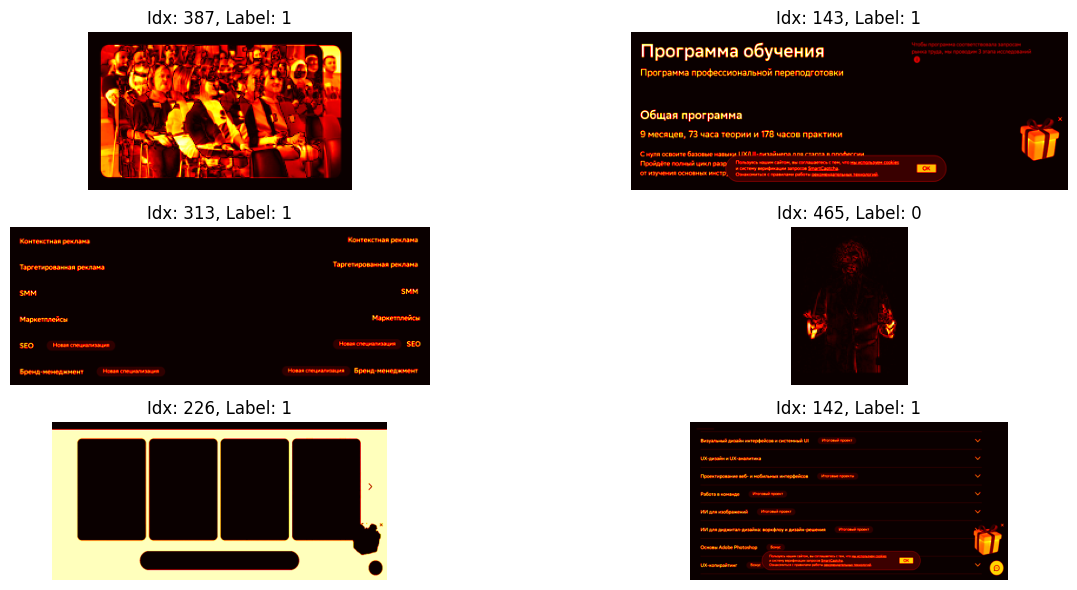

In [9]:
error_indexes = np.where(y_pred != y_test)[0]
incorrect_original_indices = idx_test[error_indexes]
print(f"Индексы с ошибками {incorrect_original_indices}")


fig, axes = plt.subplots(3, 2, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(incorrect_original_indices):
        idx = incorrect_original_indices[i]
        if idx < len(X):
            ax.imshow(X[idx], cmap='hot')
            ax.set_title(f'Idx: {idx}, Label: {y[idx]}')
            ax.axis('off')
plt.tight_layout()
plt.show()

In [10]:
y_scores = rf.predict_proba(X_test)[:, 1]

def result_with_another_treshold(my_threshold):    
    y_pred_custom = (y_scores >= my_threshold).astype(int)
    
    print(f"\n========== Результаты при пороге {my_threshold} ==========")
    print(classification_report(y_test, y_pred_custom))
    print("\nМатрица ошибок:")
    print(confusion_matrix(y_test, y_pred_custom))
    

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for t in thresholds:
    result_with_another_treshold(t)


========== Результаты при пороге 0.1 ==========
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       126
           1       0.92      1.00      0.96       120

    accuracy                           0.96       246
   macro avg       0.96      0.96      0.96       246
weighted avg       0.96      0.96      0.96       246


Матрица ошибок:
[[116  10]
 [  0 120]]

========== Результаты при пороге 0.2 ==========
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       126
           1       0.97      1.00      0.98       120

    accuracy                           0.98       246
   macro avg       0.98      0.98      0.98       246
weighted avg       0.98      0.98      0.98       246


Матрица ошибок:
[[122   4]
 [  0 120]]

========== Результаты при пороге 0.3 ==========
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       126
          

```
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       126
           1       0.98      0.95      0.97       120

    accuracy                           0.97       246
   macro avg       0.97      0.97      0.97       246
weighted avg       0.97      0.97      0.97       246
```

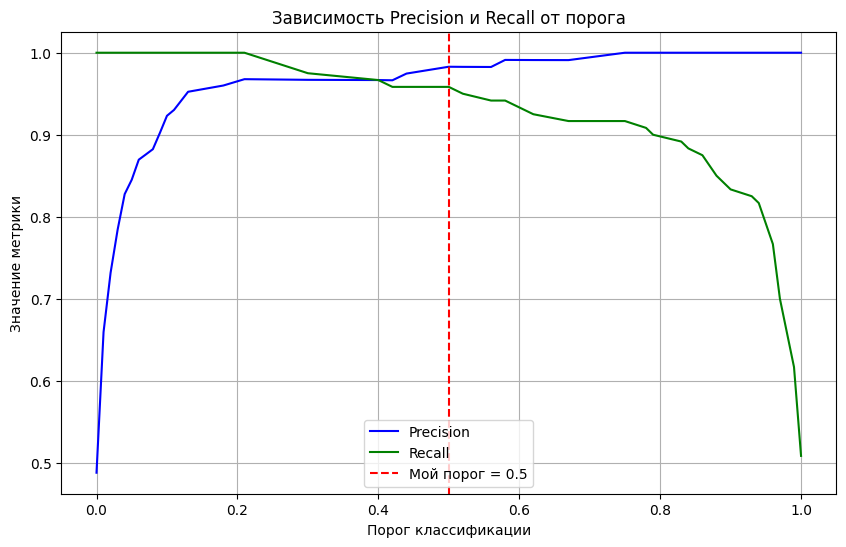

In [11]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(10, 6))
plt.plot(thresholds_pr, precisions[:-1], 'b-', label='Precision')
plt.plot(thresholds_pr, recalls[:-1], 'g-', label='Recall')
plt.xlabel('Порог классификации')
plt.ylabel('Значение метрики')
plt.title('Зависимость Precision и Recall от порога')
plt.axvline(x=0.5, color='r', linestyle='--', label='Мой порог = 0.5')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from catboost import CatBoostClassifier

catb = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=69,
    verbose=False
)
catb.fit(X_train, y_train)
y_pred = catb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       126
           1       0.98      0.97      0.97       120

    accuracy                           0.98       246
   macro avg       0.98      0.98      0.98       246
weighted avg       0.98      0.98      0.98       246



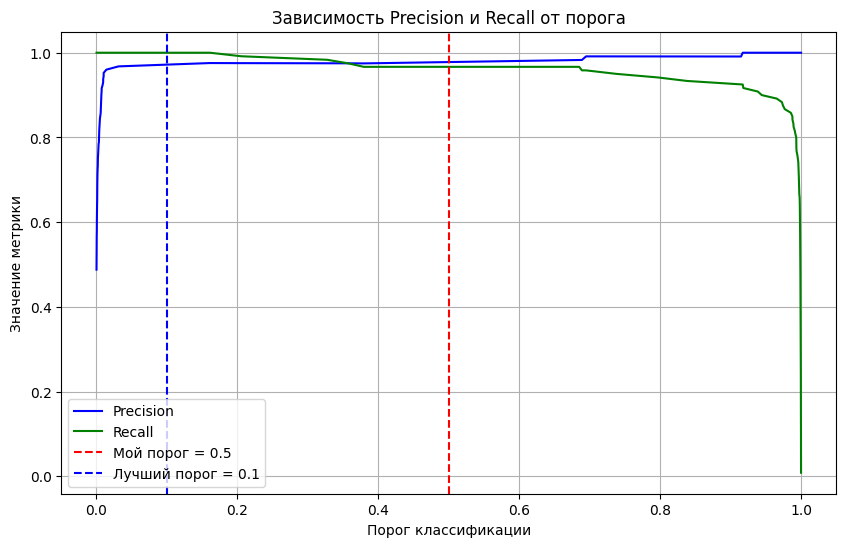

In [13]:
y_scores = catb.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(10, 6))
plt.plot(thresholds_pr, precisions[:-1], 'b-', label='Precision')
plt.plot(thresholds_pr, recalls[:-1], 'g-', label='Recall')
plt.xlabel('Порог классификации')
plt.ylabel('Значение метрики')
plt.title('Зависимость Precision и Recall от порога')
plt.axvline(x=0.5, color='r', linestyle='--', label='Мой порог = 0.5')
plt.axvline(x=0.1, color='b', linestyle='--', label='Лучший порог = 0.1')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
result_with_another_treshold(0.5)


========== Результаты при пороге 0.5 ==========
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       126
           1       0.98      0.97      0.97       120

    accuracy                           0.98       246
   macro avg       0.98      0.98      0.98       246
weighted avg       0.98      0.98      0.98       246


Матрица ошибок:
[[124   2]
 [  4 116]]


Training on fold [0/5]
0:	learn: 0.9474836	test: 0.8695652	best: 0.8695652 (0)	total: 1.93ms	remaining: 961ms
1:	learn: 0.9649891	test: 0.8869565	best: 0.8869565 (1)	total: 3.33ms	remaining: 829ms
2:	learn: 0.9781182	test: 0.9130435	best: 0.9130435 (2)	total: 4.48ms	remaining: 742ms
3:	learn: 0.9628009	test: 0.9391304	best: 0.9391304 (3)	total: 6.08ms	remaining: 755ms
4:	learn: 0.9781182	test: 0.9043478	best: 0.9391304 (3)	total: 8.7ms	remaining: 861ms
5:	learn: 0.9846827	test: 0.9217391	best: 0.9391304 (3)	total: 10.9ms	remaining: 900ms
6:	learn: 0.9868709	test: 0.9043478	best: 0.9391304 (3)	total: 13ms	remaining: 918ms
7:	learn: 0.9890591	test: 0.9043478	best: 0.9391304 (3)	total: 15.4ms	remaining: 944ms
8:	learn: 0.9890591	test: 0.9130435	best: 0.9391304 (3)	total: 17.9ms	remaining: 978ms
9:	learn: 0.9868709	test: 0.9130435	best: 0.9391304 (3)	total: 20.4ms	remaining: 1s
10:	learn: 0.9868709	test: 0.9304348	best: 0.9391304 (3)	total: 21.6ms	remaining: 960ms
11:	learn: 0.9956236	test

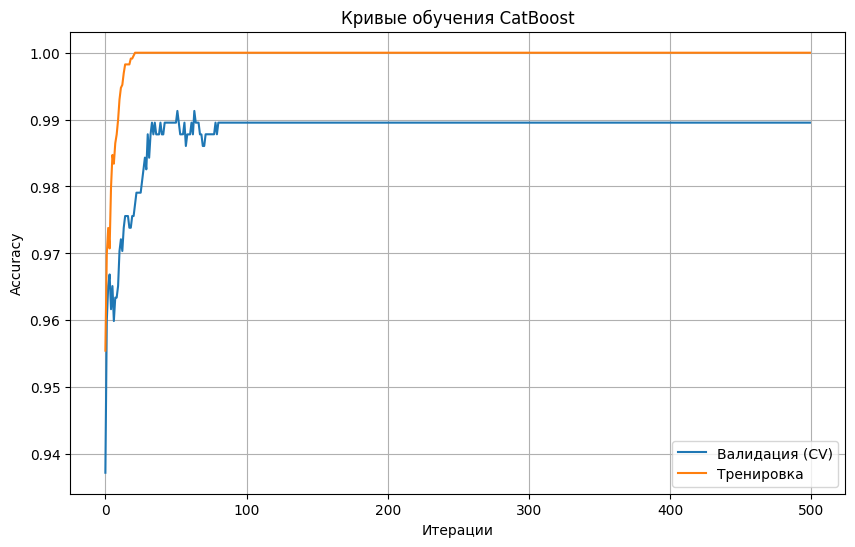

In [15]:
from catboost import Pool, cv

# Ваши данные
train_pool = Pool(X_train, y_train)
cv_params = {
    'iterations': 500,
    'depth': 6,
    'learning_rate': 0.1,
    'loss_function': 'Logloss',
    'eval_metric': 'Accuracy'
}

# Кросс-валидация с получением истории
cv_data = cv(
    params=cv_params,
    pool=train_pool,
    fold_count=5,
    shuffle=True,
    return_models=False
)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(cv_data['iterations'], cv_data['test-Accuracy-mean'], label='Валидация (CV)')
plt.plot(cv_data['iterations'], cv_data['train-Accuracy-mean'], label='Тренировка')
plt.xlabel('Итерации')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Кривые обучения CatBoost')
plt.grid()
plt.show()

In [16]:
X = joblib.load('X_cropped_diff_images_6_overeducation3.joblib')
X_coords = joblib.load('X_coords_diff_images_6_overeducation3.joblib')
y = joblib.load('y_labels_6_overeducation3.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

Загружено 3774 изображений
Загружено 3774 координат левого верхнегно угла
Загружено 3774 лейблов


In [17]:
df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]

# Создаём метки подтипов на основе индексов
subtype_labels = []
for i in range(len(df_features)):
    if i < 20:
        subtype_labels.append('disappeared')
    elif i < 40:
        subtype_labels.append('color_change')
    elif i < 70:
        subtype_labels.append('shift')
    elif i < 88:
        subtype_labels.append('dynamic')
    else:
        subtype_labels.append('banner')

subtype_labels = np.array(subtype_labels)

X_features = df_features.drop(['sample_id'], axis=1)
original_indices = np.arange(len(X_features))

y_pred = catb.predict(X_features)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.48      0.65      3774
           1       0.00      0.00      0.00         0

    accuracy                           0.48      3774
   macro avg       0.50      0.24      0.32      3774
weighted avg       1.00      0.48      0.65      3774



/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
